# Simulação de placa térmica:
### Estudo da transferência de calor por condução em uma placa bidimensional, utilizando discretização numérica do domínio.
#### Disciplina: SME0602 — Motores Numéricos para Simulação em Engenharia
#### Professor: Roberto F. Ausas
#### Grupo 3: 
* #### Beatriz Cosimatti
* #### Cecilia Queiroz
* #### Gabriel Zago
* #### Matheus Buzzon
* #### Pedro Vale
* #### Victor Silva


In [2]:
# Importações!!!

import sys
import os
import importlib

root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if root not in sys.path:
    sys.path.insert(0, root)

import thermal
importlib.reload(thermal)
import env
importlib.reload(env)
config = env.CONFIG_T

#### O sistema térmico foi implementado a partir de uma classe base capaz de resolver o problema tanto via fatoração de Cholesky quanto utilizando matrizes esparsas da biblioteca scipy, conforme orientado nas anotações.

Resultados para classe: Thermal
Resolvido por: cholesky
Número de discretizações: (101, 51)
Condutividade térmica utilizada: 0.25 W/mK
Fonte térmica utilizada: 5.0e+05 W/m³


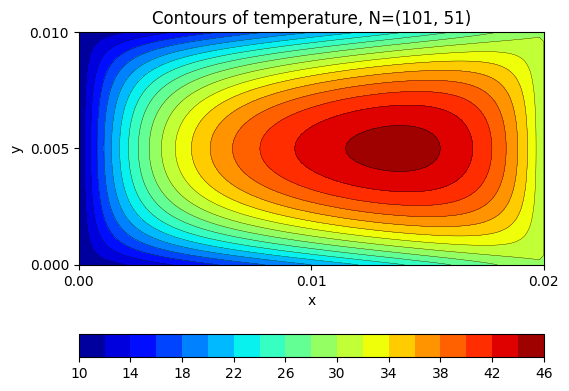

In [3]:
placa_termica_cholesky = thermal.Thermal(config = config, method = "cholesky")
placa_termica_cholesky.run(print_info=True, plot=True)

Resultados para classe: Thermal
Resolvido por: sparse
Número de discretizações: (101, 51)
Condutividade térmica utilizada: 0.25 W/mK
Fonte térmica utilizada: 5.0e+05 W/m³


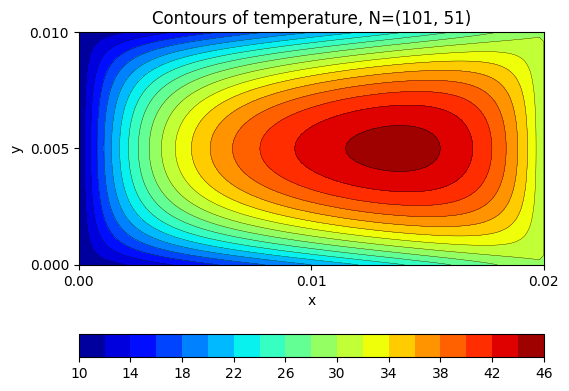

In [4]:
placa_termica_sparse = thermal.Thermal(config = config, method = "sparse")
placa_termica_sparse.run(print_info=True, plot=True)

##### O primeiro estudo analisa a complexidade computacional dos métodos de Cholesky e sparse para diferentes níveis de discretização. Os testes foram realizados em dois computadores distintos para reduzir a influência do ambiente, e os resultados obtidos são apresentados a seguir:

![Resultados analise_complex_cholesky_vs_sparse para um computador](resultados_p1/tempos_medidos.png)


![Resultados analise_complex_cholesky_vs_sparse para outro computador](resultados_p1/tempos_medidos2.png)

##### As malhas geradas pela implementação estão de acordo com o esperado para as discretizações propostas:

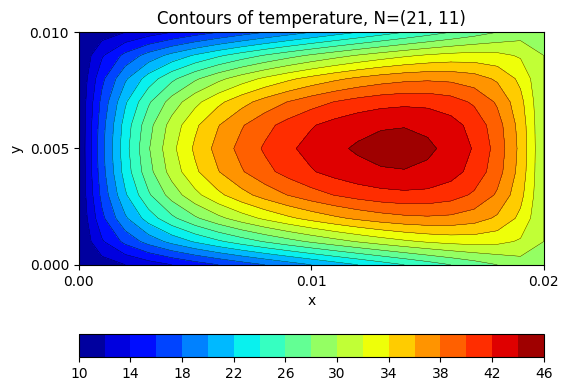

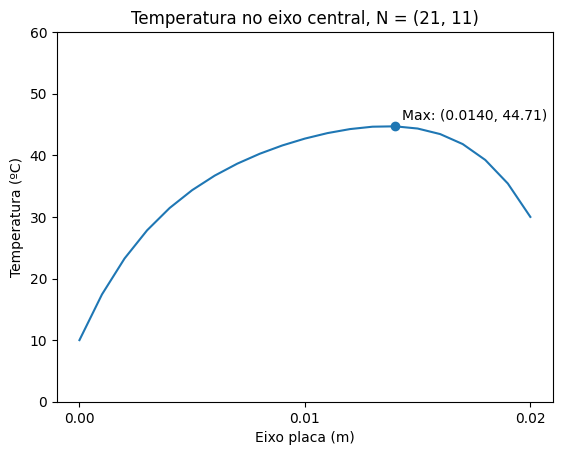

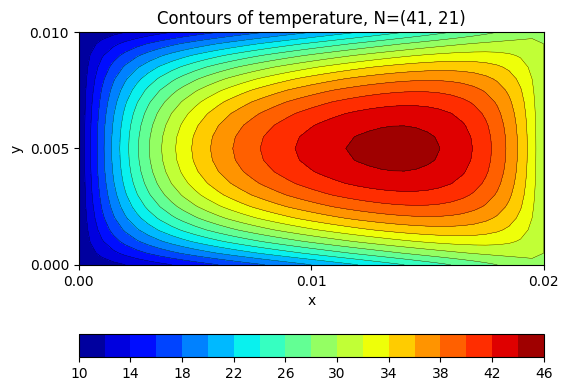

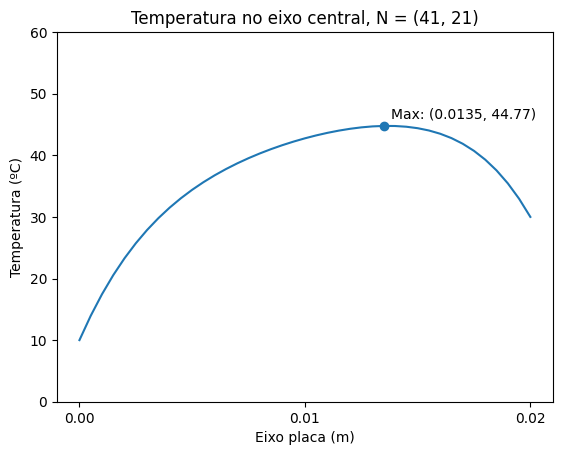

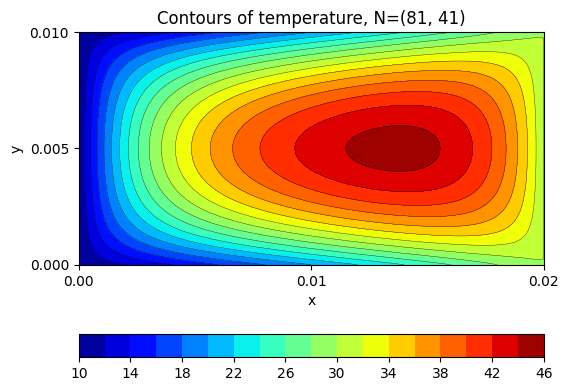

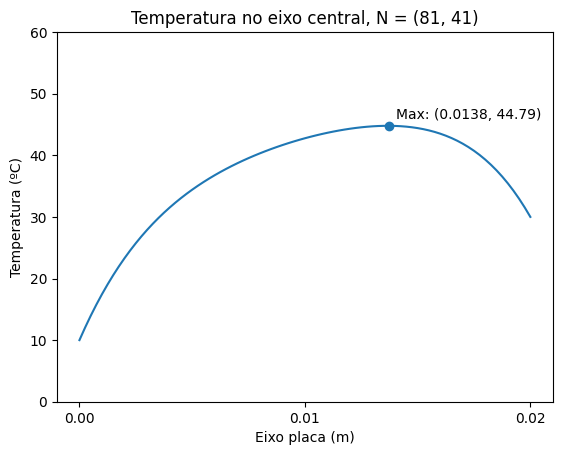

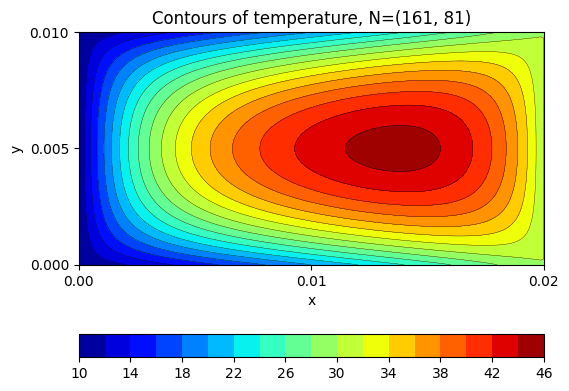

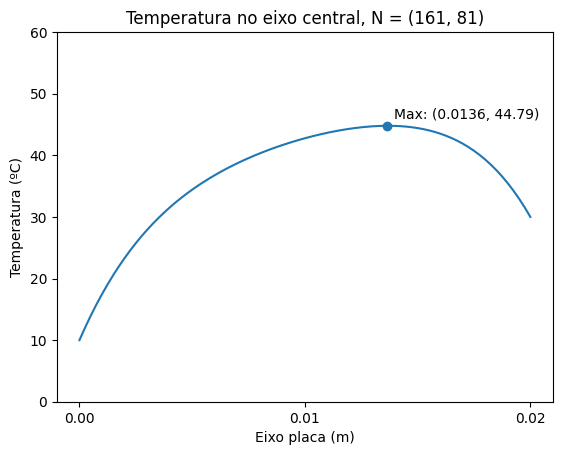

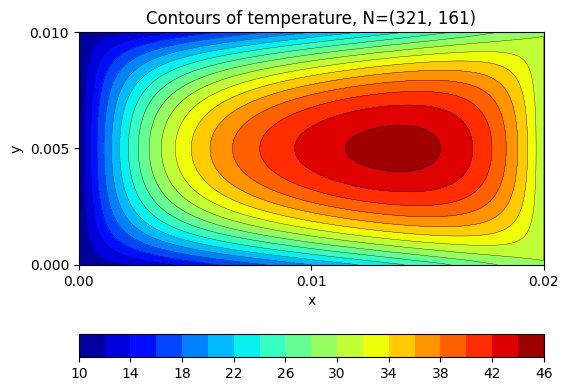

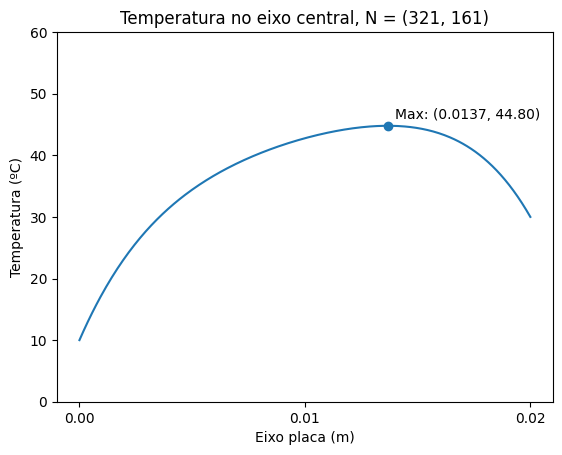

In [5]:
analise_complex_cholesky_vs_sparse = thermal.Thermal_P1(config = config, method = "sparse")
analise_complex_cholesky_vs_sparse.run(plot = True)

##### No segundo estudo, analisamos o comportamento da placa ao introduzir uma região circular com temperatura fixa, avaliando o efeito para diferentes discretizações.

Resultados para classe: Thermal_P2
Resolvido por: sparse
Raio do círculo: 0.002 m
Temperatura no círculo: 30 °C


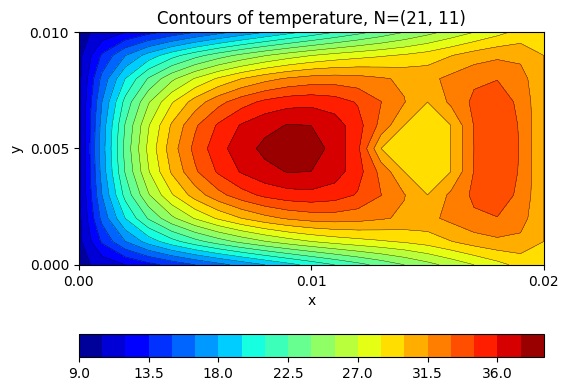

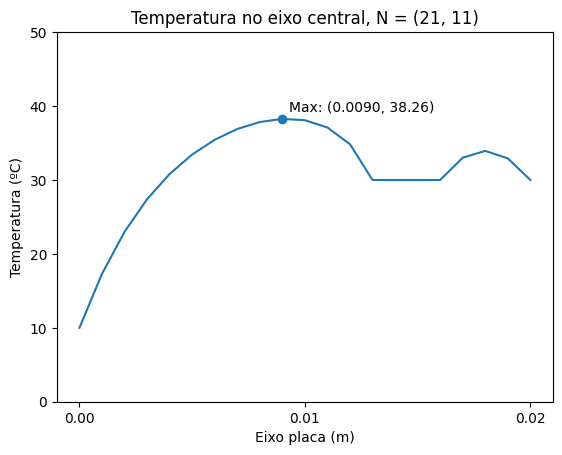

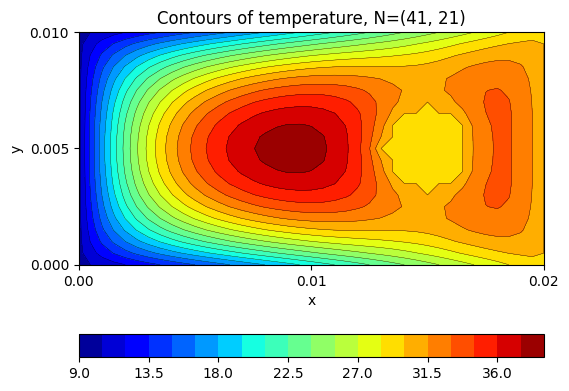

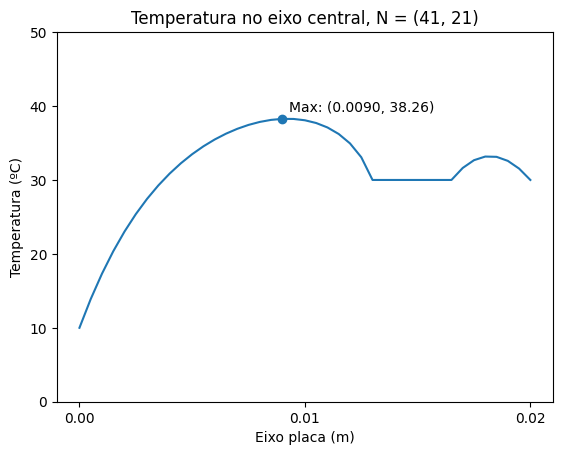

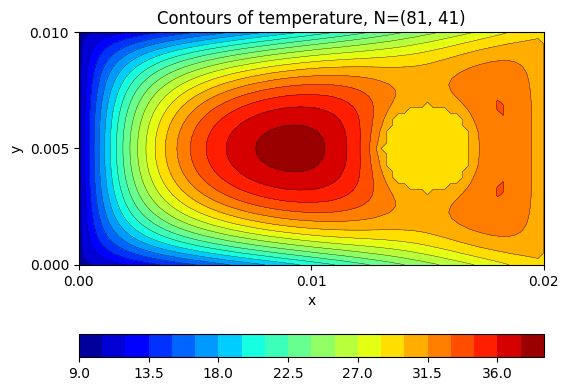

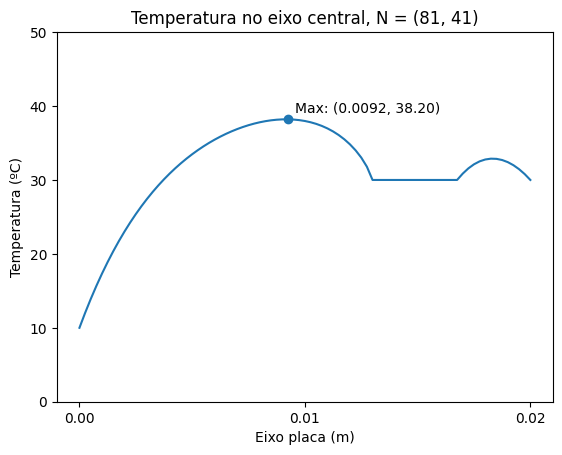

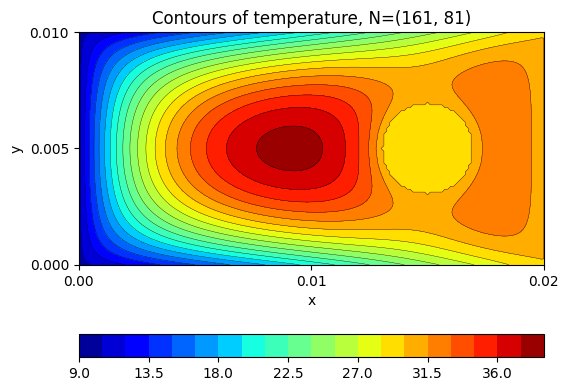

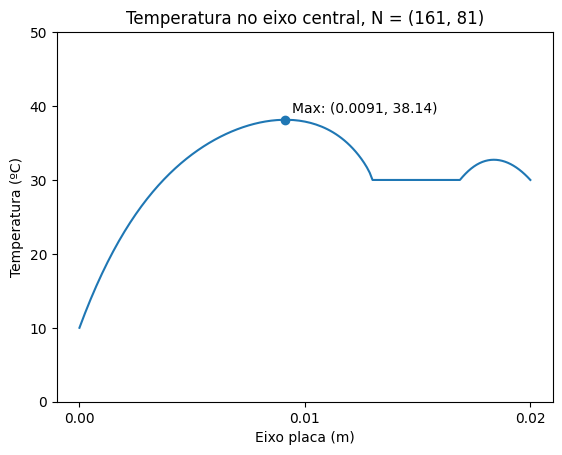

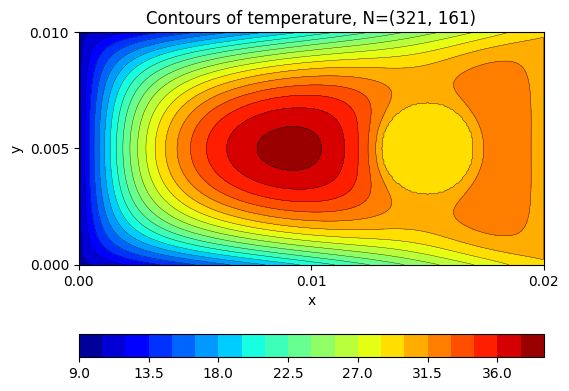

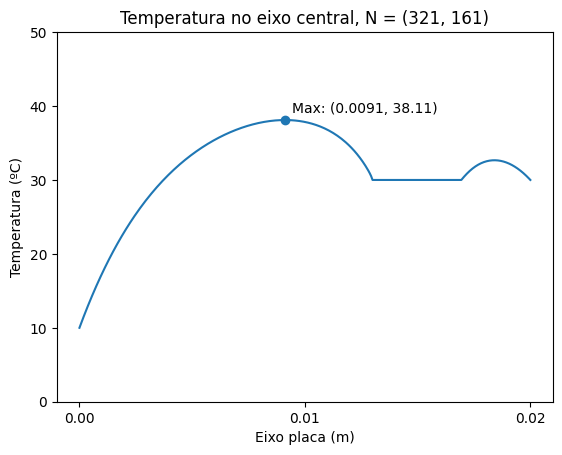

In [6]:
analise_regiao_circular = thermal.Thermal_P2(config = config, method = "sparse")
analise_regiao_circular.run(print_info = True, plot = True)

##### O terceiro estudo considera uma condutividade térmica variável, definida como uma função trigonométrica da posição na placa, e investiga seu impacto na distribuição de temperatura.

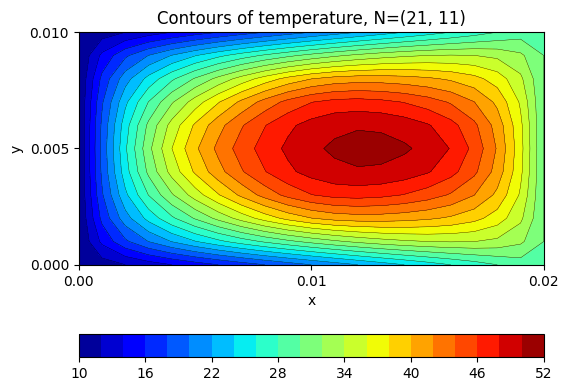

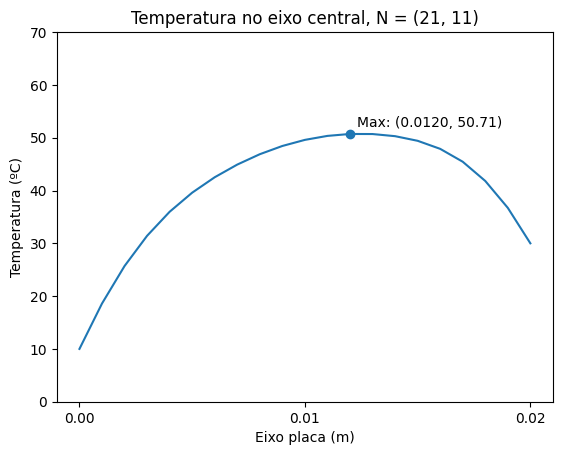

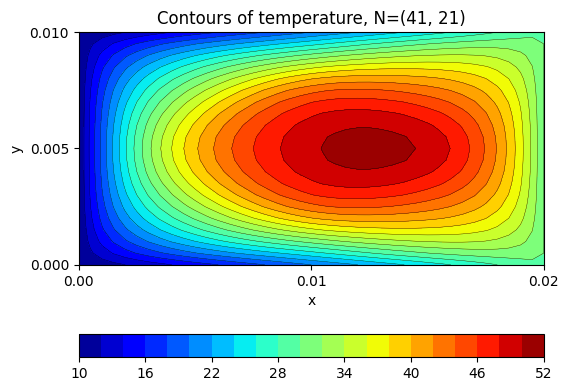

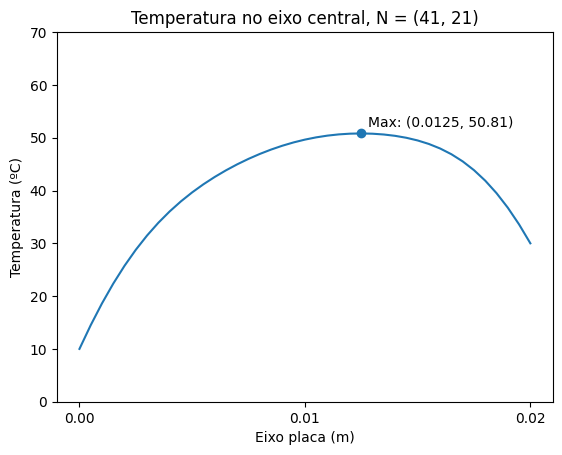

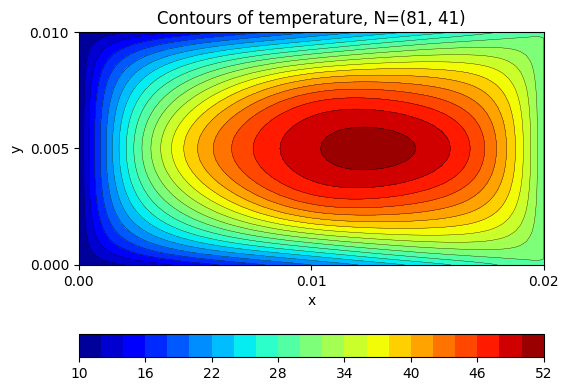

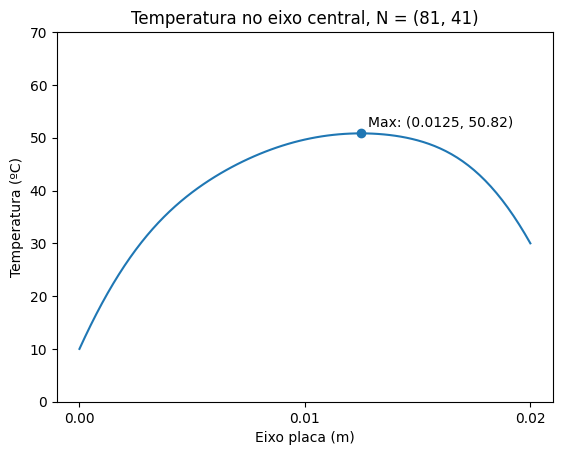

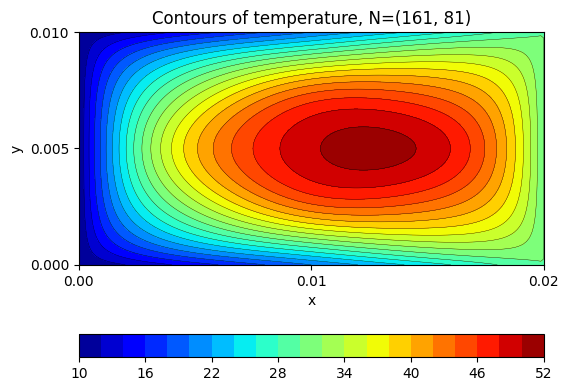

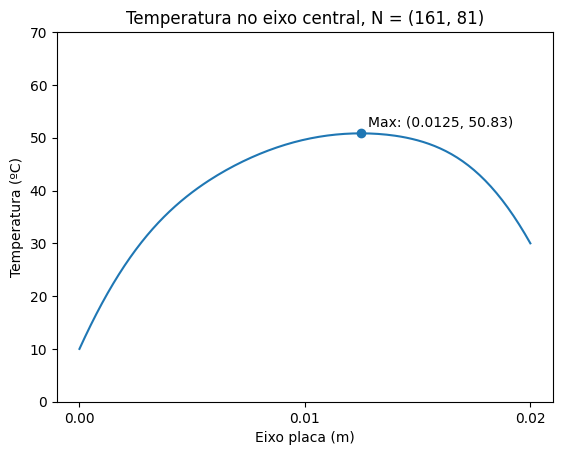

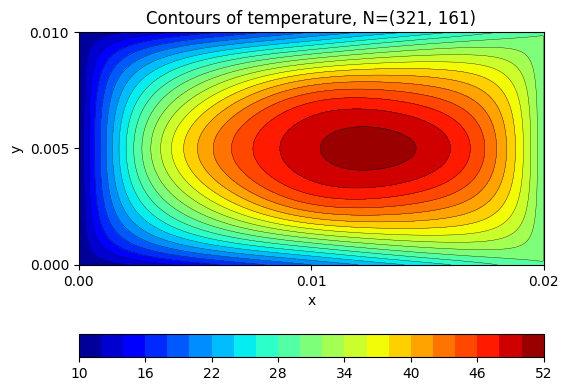

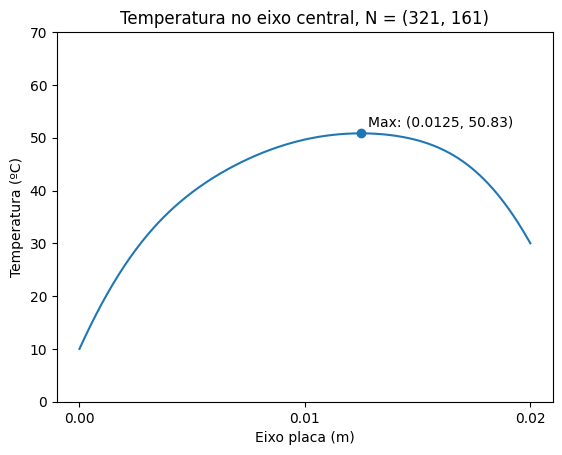

In [7]:
analise_k_variavel = thermal.Thermal_P3(config = config, method = "sparse")
analise_k_variavel.run(plot = True)

##### O quarto estudo estende o caso da região circular, analisando o efeito de diferentes temperaturas impostas nessa região sobre o comportamento global do sistema.

Resultados para classe: Thermal_P4
Resolvido por: sparse
Número de discretizações: (101, 51)


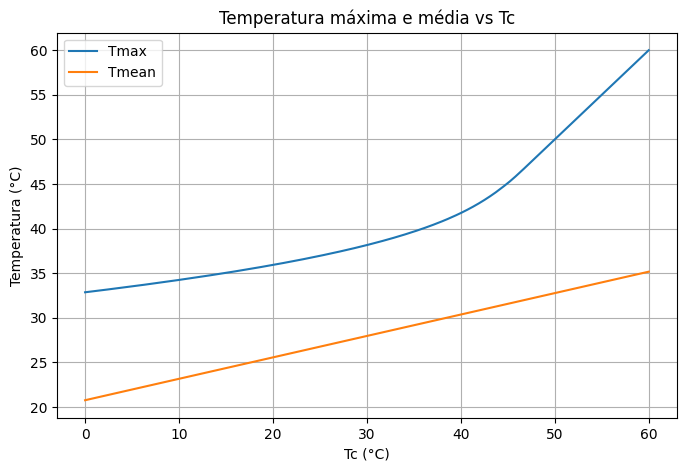

In [8]:
analise_regiao_circular_varias_temps = thermal.Thermal_P4(config = config, method = "sparse")
analise_regiao_circular_varias_temps.run(print_info = True, plot = True)

##### No quinto estudo, exploramos a linearidade do sistema. A temperatura em um nó k pode ser expressa como combinação linear das condições de contorno:
#### Tk = a⋅Tc + b⋅Tr + c
##### onde Tc é a temperatura da região circular e Tr da borda direita. Os coeficientes a, b e c foram determinados numericamente.

In [9]:
analise_linearidade = thermal.Thermal_P5(config=config, method="sparse")
analise_linearidade.run(print_info = True)


--- Problema 5 ---

Coeficientes encontrados (nó k=233)
  a = 0.00003821   (sensibilidade a T_R)
  b = 0.01286422   (sensibilidade a T_C)
  c = 18.97207591   (termo independente)

Equação linear
  T_233 = 0.000038·T_R  +  0.012864·T_C  +  18.972076


### Métodos iterativos

##### Neste estudo, comparamos os métodos iterativos de Jacobi e Gauss-Seidel, analisando o tempo de convergência em função do tamanho da malha e da tolerância adotada.

![Resultados 1 do método iterativo](resultados_p1_extra/tempoXsubdivisoes_1.png)

![Resultados 2 do método iterativo](resultados_p1_extra/tempoXsubdivisoes_2.png)

![Resultados 3 do método iterativo](resultados_p1_extra/tempoXtolerancia.png)


##### A animação abaixo ilustra o processo de convergência dos métodos iterativos ao longo das iterações.

In [12]:
from IPython.display import Video
Video("resultados_p1_extra/Animacao_Termica.mp4", width=1100)

##### Por fim, investigamos qual deve ser a temperatura na região circular para que a temperatura máxima da placa atinja um valor desejado Tmax.


In [13]:
encontrar_Tc_para_Tmax_definido = thermal.SolucionadorTermicoIterativo(config)
encontrar_Tc_para_Tmax_definido.run()


    Nx     Ny    N_nos   t_mont(s)  t_resolv(s)   Iters   T_max(C)       T_C(C)
-------------------------------------------------------------------------------
    21     11      231      0.0010       0.0197      26    39.5001      34.2883
    41     21      861      0.0012       0.0415      25    39.5001      34.2495
    81     41     3321      0.0043       0.2370      26    39.5001      34.4156
   161     81    13041      0.0180       0.8983      25    39.5001      34.5515
   321    161    51681      0.0742       5.5352      24    39.5001      34.6376
